In [4]:
# EDA - NOMIS Vacancy Data
# checking what the vacancy dataset looks like before cleaning

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # hiding the openpyxl style warning

# nomis files have metadata in the first few rows so skipping them
df = pd.read_excel('NOMIS_Vacancies_13Jun2026.xlsx', skiprows=6)

# basic check
print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist())
print("\nfirst 5 rows:")
print(df.head())

shape: (210, 21)

columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']

first 5 rows:
       Unnamed: 0                             Unnamed: 1  \
0            Date  A : Agriculture, forestry and fishing   
1      March 2021                                 375010   
2       June 2021                                 374908   
3  September 2021                                 365821   
4   December 2021                                 347493   

                 Unnamed: 2         Unnamed: 3  \
0  B : Mining and quarrying  C : Manufacturing   
1                     53082            2538058   
2                     53464            2544919   
3                     52171            2534972   
4                     50999            25

In [5]:
# fixing the column names - first row has the actual headers
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

# renaming the date column so its easier to work with
df = df.rename(columns={df.columns[0]: 'Date'})

print("columns:", df.columns.tolist())
print("shape:", df.shape)
print("date range:", df['Date'].iloc[0], "to", df['Date'].iloc[-1])

columns: ['Date', 'A : Agriculture, forestry and fishing', 'B : Mining and quarrying', 'C : Manufacturing', 'D : Electricity, gas, steam and air conditioning supply', 'E : Water supply; sewerage, waste management and remediation activities', 'F : Construction', 'G : Wholesale and retail trade; repair of motor vehicles and motorcycles', 'H : Transportation and storage', 'I : Accommodation and food service activities', 'J : Information and communication', 'K : Financial and insurance activities', 'L : Real estate activities', 'M : Professional, scientific and technical activities', 'N : Administrative and support service activities', 'O : Public administration and defence; compulsory social security', 'P : Education', 'Q : Human health and social work activities', 'R : Arts, entertainment and recreation', 'S : Other service activities', 'T : Activities of households as employers;undifferentiated goods-and services-producing activities of households for own use']
shape: (209, 21)
date ran

In [8]:
# checking for missing values
print("missing values:")
print(df.isnull().sum())

missing values:
0
Date                                                                                                                            30
A : Agriculture, forestry and fishing                                                                                           45
B : Mining and quarrying                                                                                                        63
C : Manufacturing                                                                                                               63
D : Electricity, gas, steam and air conditioning supply                                                                         63
E : Water supply; sewerage, waste management and remediation activities                                                         63
F : Construction                                                                                                                63
G : Wholesale and retail trade; repair of motor vehicles and moto

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# only keeping rows that look like actual quarters e.g. "March 2021"
months = ['March', 'June', 'September', 'December']
df_clean = df[df['Date'].apply(lambda x: any(m in str(x) for m in months))].copy()

# my 5 dissertation sectors
sectors = {
    'Education': 'P : Education',
    'Healthcare': 'Q : Human health and social work activities',
    'Finance': 'K : Financial and insurance activities',
    'Construction': 'F : Construction',
    'Info & Comms': 'J : Information and communication'
}

colors = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']

# converting to numeric
for col in sectors.values():
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("rows after cleaning:", len(df_clean))
print("dates:", df_clean['Date'].tolist())



rows after cleaning: 146
dates: ['March 2021', 'June 2021', 'September 2021', 'December 2021', 'March 2022', 'June 2022', 'September 2022', 'December 2022', 'March 2023', 'June 2023', 'September 2023', 'December 2023', 'March 2024', 'June 2024', 'September 2024', 'December 2024', 'March 2025', 'June 2025', 'September 2025', 'December 2025', 'ONS Crown Copyright Reserved [from Nomis on 13 June 2026]', 'March 2021', 'June 2021', 'September 2021', 'December 2021', 'March 2022', 'June 2022', 'September 2022', 'December 2022', 'March 2023', 'June 2023', 'September 2023', 'December 2023', 'March 2024', 'June 2024', 'September 2024', 'December 2024', 'March 2025', 'June 2025', 'September 2025', 'December 2025', 'ONS Crown Copyright Reserved [from Nomis on 13 June 2026]', 'March 2021', 'June 2021', 'September 2021', 'December 2021', 'March 2022', 'June 2022', 'September 2022', 'December 2022', 'March 2023', 'June 2023', 'September 2023', 'December 2023', 'March 2024', 'June 2024', 'September 2

In [17]:
# just taking the first 20 rows - thats one clean set of quarters 2021-2025
df_clean = df_clean.iloc[:20].copy()

print("rows now:", len(df_clean))
print("dates:", df_clean['Date'].tolist())

rows now: 20
dates: ['March 2021', 'June 2021', 'September 2021', 'December 2021', 'March 2022', 'June 2022', 'September 2022', 'December 2022', 'March 2023', 'June 2023', 'September 2023', 'December 2023', 'March 2024', 'June 2024', 'September 2024', 'December 2024', 'March 2025', 'June 2025', 'September 2025', 'December 2025']


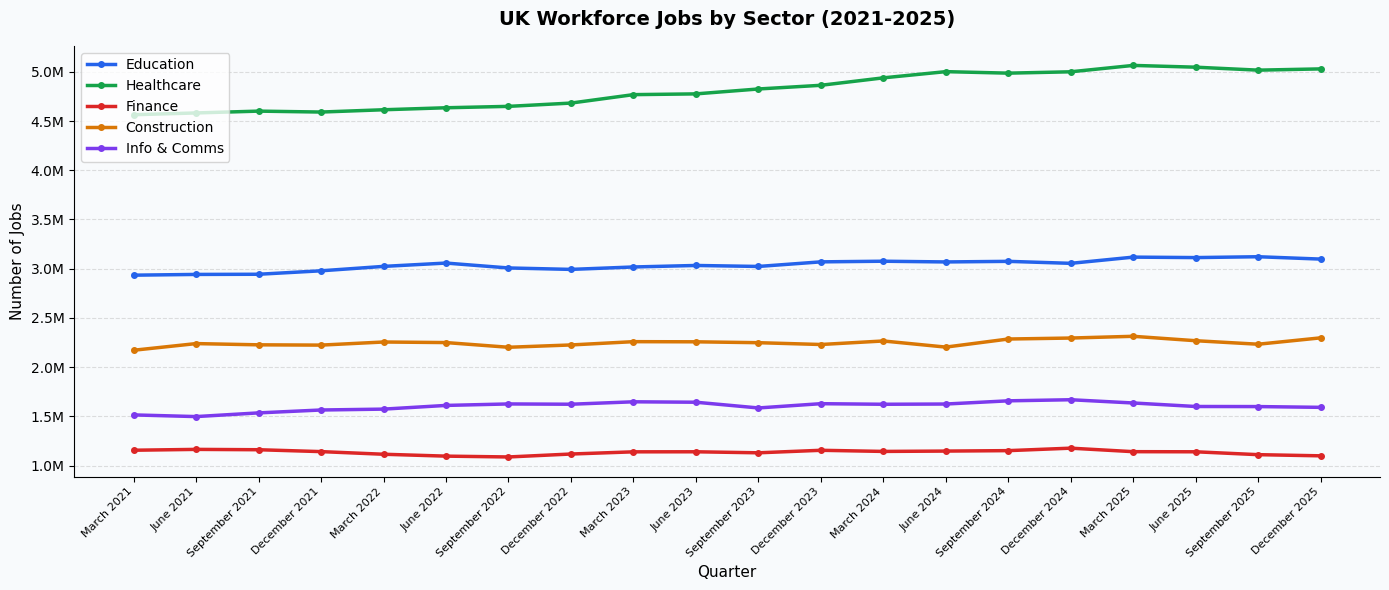

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')

for (label, col), color in zip(sectors.items(), colors):
    ax.plot(range(len(df_clean)), df_clean[col],
            label=label, color=color, linewidth=2.5, marker='o', markersize=4)

ax.set_title('UK Workforce Jobs by Sector (2021-2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Number of Jobs', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xticks(range(len(df_clean)))
ax.set_xticklabels(df_clean['Date'], rotation=45, ha='right', fontsize=8)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('nomis_vacancies_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# notes for sprint 2 cleaning
print("key findings from NOMIS EDA:")
print("- date range: March 2021 to December 2025 (20 quarters)")
print("- Healthcare is the biggest sector and growing steadily")
print("- Finance is the smallest of the 5 sectors, fairly flat")
print("- file has multiple repeated sections - need to handle in Sprint 2 cleaning")
print("- footnote rows present in data - need to strip in Sprint 2")

key findings from NOMIS EDA:
- date range: March 2021 to December 2025 (20 quarters)
- Healthcare is the biggest sector and growing steadily
- Finance is the smallest of the 5 sectors, fairly flat
- file has multiple repeated sections - need to handle in Sprint 2 cleaning
- footnote rows present in data - need to strip in Sprint 2
